In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import perform_svd

Original Matrix A (2x3):
[[1. 2. 3.]
 [4. 5. 6.]]

Matrix U ((2, 2)):
[[-0.3863177  -0.92236578]
 [-0.92236578  0.3863177 ]]

Singular Values Σ (vector): [9.508032   0.77286964]
Σ as diagonal matrix:
[[9.508032   0.        ]
 [0.         0.77286964]]

Matrix V^T ((2, 3)):
[[-0.42866713 -0.56630692 -0.7039467 ]
 [ 0.80596391  0.11238241 -0.58119908]]

Reconstructed Matrix:
[[1. 2. 3.]
 [4. 5. 6.]]

Reconstruction Error (Frobenius norm): 2.75e-15
Verification: A = UΣV^T? True


## Visualize the Singular Values and Matrix Approximation

Matrix A (2x3):
[[ 3.  2.  2.]
 [ 2.  3. -2.]]



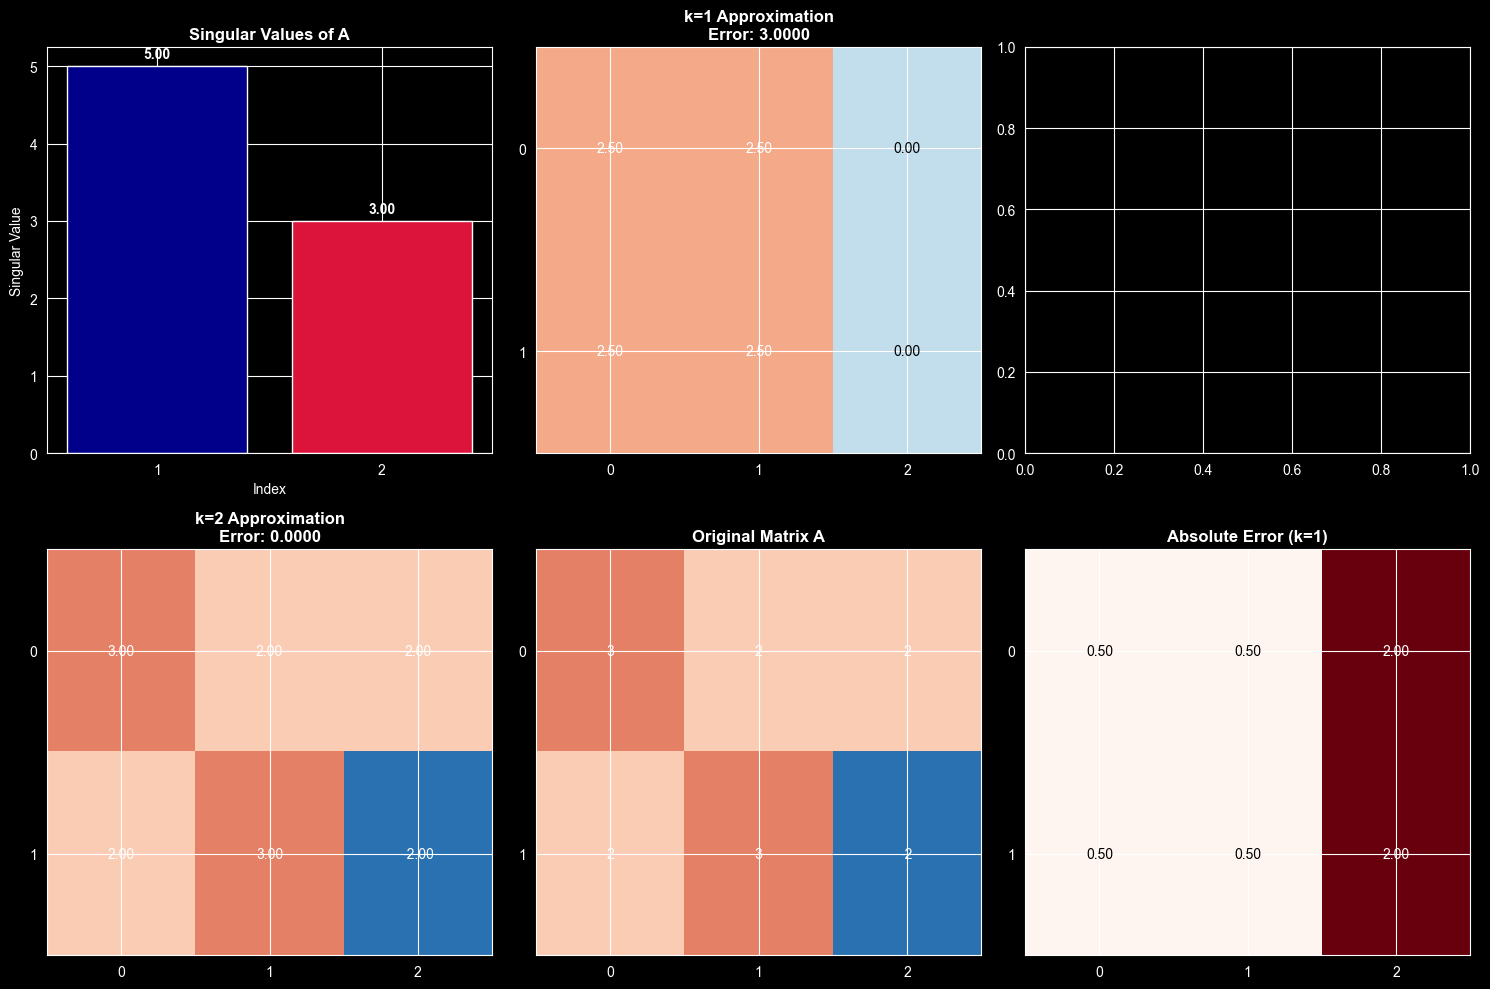


Singular values: [5. 3.]
Energy captured by k=1: 73.53%
Energy captured by k=2: 100.00%


In [2]:
A_task2 = np.array([[3, 2, 2],
                    [2, 3, -2]], dtype=float)

print(f"Matrix A (2x3):\n{A_task2}\n")

U2, s2, Vt2 = perform_svd(A_task2)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Singular values
ax = axes[0, 0]
ax.bar(range(1, len(s2)+1), s2, color=['darkblue', 'crimson'])
ax.set_xlabel('Index')
ax.set_ylabel('Singular Value')
ax.set_title('Singular Values of A', fontweight='bold')
ax.set_xticks(range(1, len(s2)+1))
for i, v in enumerate(s2):
    ax.text(i+1, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Function to create low-rank approximation
def low_rank_approx(U, s, Vt, k):
    """Reconstruct matrix using top k singular values"""
    U_k = U[:, :k]
    s_k = s[:k]
    Vt_k = Vt[:k, :]
    Sigma_k = np.diag(s_k)
    return U_k @ Sigma_k @ Vt_k

# Plot approximations for different k values
k_values = [1, 2]
for idx, k in enumerate(k_values):
    ax = axes[0, idx+1] if idx == 0 else axes[1, 0]

    A_approx = low_rank_approx(U2, s2, Vt2, k)
    error = np.linalg.norm(A_task2 - A_approx)

    im = ax.imshow(A_approx, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=5)
    ax.set_title(f'k={k} Approximation\nError: {error:.4f}', fontweight='bold')
    ax.set_xticks(range(A_task2.shape[1]))
    ax.set_yticks(range(A_task2.shape[0]))

    # Add values to cells
    for i in range(A_approx.shape[0]):
        for j in range(A_approx.shape[1]):
            ax.text(j, i, f'{A_approx[i, j]:.2f}', ha='center', va='center',
                   color='white' if abs(A_approx[i, j]) > 1 else 'black', fontsize=10)

# Plot original matrix
ax = axes[1, 1]
im = ax.imshow(A_task2, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=5)
ax.set_title('Original Matrix A', fontweight='bold')
ax.set_xticks(range(A_task2.shape[1]))
ax.set_yticks(range(A_task2.shape[0]))
for i in range(A_task2.shape[0]):
    for j in range(A_task2.shape[1]):
        ax.text(j, i, f'{A_task2[i, j]:.0f}', ha='center', va='center',
               color='white' if abs(A_task2[i, j]) > 1 else 'black', fontsize=10)

# Plot error heatmap for k=1
ax = axes[1, 2]
A_k1 = low_rank_approx(U2, s2, Vt2, 1)
error_matrix = np.abs(A_task2 - A_k1)
im = ax.imshow(error_matrix, cmap='Reds', aspect='auto')
ax.set_title('Absolute Error (k=1)', fontweight='bold')
ax.set_xticks(range(A_task2.shape[1]))
ax.set_yticks(range(A_task2.shape[0]))
for i in range(error_matrix.shape[0]):
    for j in range(error_matrix.shape[1]):
        ax.text(j, i, f'{error_matrix[i, j]:.2f}', ha='center', va='center',
               color='white' if error_matrix[i, j] > 1 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nSingular values: {s2}")
print(f"Energy captured by k=1: {s2[0]**2/np.sum(s2**2)*100:.2f}%")
print(f"Energy captured by k=2: {np.sum(s2**2)/np.sum(s2**2)*100:.2f}%")